In [1]:
import shutil
import requests
from pycelonis import get_celonis
from pycelonis.pql import PQL, PQLColumn, OrderByColumn
import os
from dotenv import load_dotenv
import pandas as pd 
from pathlib import Path
from run_workflow_open import run_batch_inference
import re


load_dotenv()

BASE_URL = os.getenv('BASE_URL') or ''
APP_TOKEN = os.getenv('APP_TOKEN') or ''
BUCKET_ID = os.getenv('BUCKET_ID') or ''

TIMEOUT = 20
HEADER = {'Authorization': "AppKey " + APP_TOKEN}
INPUT_FOLDER = "./data/inputs/celonis/"
dirpath = Path(INPUT_FOLDER)
if dirpath.exists() and dirpath.is_dir():
    shutil.rmtree(dirpath)
os.makedirs(INPUT_FOLDER, exist_ok=True)
OUTPUT_FOLDER = "./data/output/celonis"
dirpath = Path(OUTPUT_FOLDER)
if dirpath.exists() and dirpath.is_dir():
    shutil.rmtree(dirpath)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)
DATA_POOL_ID = os.getenv('DATA_POOL_ID') or ''
DATA_MODEL_ID = os.getenv('DATA_MODEL_ID') or ''

celonis = get_celonis(base_url=BASE_URL, api_token=APP_TOKEN, key_type='APP_KEY')

data_pool = celonis.data_integration.get_data_pool(DATA_POOL_ID)
data_model = data_pool.get_data_model(DATA_MODEL_ID)
print(data_model.name)

query = PQL(distinct=False, limit=None, offset=None)
#query += PQLColumn(name="CaseId", query=""" "user_interaction_event_log"."Id" """)
query += PQLColumn(name="TimestampLocal", query=""" "user_interaction_event_log"."TimestampLocal" """)
query += OrderByColumn(query=""" "user_interaction_event_log"."TimestampLocal" """, ascending=False)
#query += PQLColumn(name="EventDescription", query=""" "user_interaction_event_log"."EventDescription" """)
query += PQLColumn(name="ProcessName", query=""" "user_interaction_event_log"."ProcessName" """)
query += PQLColumn(name="EventType", query=""" "user_interaction_event_log"."EventType" """)
query += PQLColumn(name="ClipboardContent", query=""" "user_interaction_event_log"."ClipboardText" """)
query += PQLColumn(name="ActiveWindow", query=""" "user_interaction_event_log"."ActiveWindow" """)
query += PQLColumn(name="MousePositionX", query=""" "user_interaction_event_log"."MousePositionX" """)
query += PQLColumn(name="MousePositionY", query=""" "user_interaction_event_log"."MousePositionY" """)
query += PQLColumn(name="ScreenshotId", query=""" "user_interaction_event_log"."ScreenshotId" """)
query += PQLColumn(name="UserId", query=""" "user_interaction_event_log"."UserId" """)


result_df = data_model.export_data_frame(query)
#result_df = result_df[result_df["CaseId"] == "2023-08-126cb666bc-245c-40c9-9d06-4d448ab71c78"]
# result_df = result_df[result_df["CaseId"] == "2023-08-12858e14d1-1026-403a-a519-90d3df2cf616"]
# result_df = result_df[result_df["CaseId"] == "2023-06-182e756d3e-1a0e-4a22-bd18-893f1369af79"]
# result_df["TimestampLocal"] = pd.to_datetime(result_df["TimestampLocal"])
result_df = result_df.sort_values(by='TimestampLocal', ascending=True)
#result_df = result_df[result_df["ScreenshotId"] != ""]
result_df = result_df.dropna(subset=['ScreenshotId'])
result_df = result_df.dropna(subset=['MousePositionX'])
# result_df = result_df[13:16]
#result_df = result_df.tail(4)
result_df = result_df[result_df["ProcessName"] == "chrome"]
result_df = result_df.sort_values(by='TimestampLocal', ascending=True)
result_df = result_df.reset_index(drop=True)
result_df

[2025-05-06 12:56:05,796] [ WARNING] __init__.py:334 - Your PyCelonis Version 2.12.0 is outdated (Newest Version: 2.13.0). Please upgrade the package via: pip install --extra-index-url=https://pypi.celonis.cloud/ pycelonis pycelonis_core --upgrade


Task Mining Data Model - JiraWorkflow


,TimestampLocal,ProcessName,EventType,ClipboardContent,ActiveWindow,MousePositionX,MousePositionY,ScreenshotId,UserId
0,2025-03-06 16:19:38.250,chrome,Left click,None,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",928.0,359.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
1,2025-03-06 16:19:48.419,chrome,Left click,None,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",949.0,435.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
2,2025-03-06 16:20:11.287,chrome,Left click,None,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",948.0,485.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
3,2025-03-06 16:20:19.432,chrome,Left click,None,Projects - Jira - Google Chrome,394.0,374.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
4,2025-03-06 16:20:27.208,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,371.0,725.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
5,2025-03-06 16:20:56.471,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,514.0,764.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
6,2025-03-06 16:20:59.661,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,639.0,968.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
7,2025-03-06 16:21:11.555,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,556.0,247.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
8,2025-03-06 16:21:13.861,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,592.0,376.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
9,2025-03-06 16:21:18.406,chrome,Left click,None,Bug Tracking System - Details - Jira - Google ...,121.0,331.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y


In [2]:
for index, row in result_df.iterrows():
    SCREENSHOT_ID = row["ScreenshotId"]
    USER_ID = row["UserId"]
    if not SCREENSHOT_ID == "":
        URL_FIRST_PART =f"{BASE_URL}/image-collector/api/v3/resources/{USER_ID}/"
        URL_SECOND_PART =f"?bucketId={BUCKET_ID}"
        URL = URL_FIRST_PART + SCREENSHOT_ID + URL_SECOND_PART

        response = requests.get(URL, headers=HEADER, timeout=TIMEOUT, stream=True)
        print(SCREENSHOT_ID + ": " + str(response))
        with open(INPUT_FOLDER + SCREENSHOT_ID, 'wb+') as out_file:
            shutil.copyfileobj(response.raw, out_file)

IMG_87447751-410d-45c4-8915-657e0a293426_000000027.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000029.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000030.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000031.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000032.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000035.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000036.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000037.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000038.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000039.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000040.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000041.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000042.png: <Response [200]>
IMG_87447751-410d-45c4-8915-657e0a293426_000000043.

In [3]:
result_df

,TimestampLocal,ProcessName,EventType,ClipboardContent,ActiveWindow,MousePositionX,MousePositionY,ScreenshotId,UserId
0,2025-03-06 16:19:38.250,chrome,Left click,None,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",928.0,359.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
1,2025-03-06 16:19:48.419,chrome,Left click,None,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",949.0,435.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
2,2025-03-06 16:20:11.287,chrome,Left click,None,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",948.0,485.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
3,2025-03-06 16:20:19.432,chrome,Left click,None,Projects - Jira - Google Chrome,394.0,374.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
4,2025-03-06 16:20:27.208,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,371.0,725.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
5,2025-03-06 16:20:56.471,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,514.0,764.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
6,2025-03-06 16:20:59.661,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,639.0,968.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
7,2025-03-06 16:21:11.555,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,556.0,247.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
8,2025-03-06 16:21:13.861,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,592.0,376.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
9,2025-03-06 16:21:18.406,chrome,Left click,None,Bug Tracking System - Details - Jira - Google ...,121.0,331.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y


In [4]:
app_name = "Jira"
full_jsons = run_batch_inference(INPUT_FOLDER+"*", app_name, OUTPUT_FOLDER)

[Batch Init started]
Using extended model for activity name generation
[Generation started for: ./data/inputs/celonis/IMG_87447751-410d-45c4-8915-657e0a293426_000000027.png]
[Generation Completed in 3.027 s]
[Generation started for: ./data/inputs/celonis/IMG_87447751-410d-45c4-8915-657e0a293426_000000029.png]
[Generation Completed in 2.668 s]
[Generation started for: ./data/inputs/celonis/IMG_87447751-410d-45c4-8915-657e0a293426_000000030.png]
[Generation Completed in 2.406 s]
[Generation started for: ./data/inputs/celonis/IMG_87447751-410d-45c4-8915-657e0a293426_000000031.png]
[Generation Completed in 2.428 s]
[Generation started for: ./data/inputs/celonis/IMG_87447751-410d-45c4-8915-657e0a293426_000000032.png]
[Generation Completed in 2.927 s]
[Generation started for: ./data/inputs/celonis/IMG_87447751-410d-45c4-8915-657e0a293426_000000035.png]
[Generation Completed in 3.145 s]
[Generation started for: ./data/inputs/celonis/IMG_87447751-410d-45c4-8915-657e0a293426_000000036.png]
[Gen

In [5]:
def find_smallest_bbox(entries, mousepos_x, mousepos_y):
    smallest_entry = None
    smallest_area = float('inf')

    for entry in entries:
        x1, y1, x2, y2 = entry["bbox"]['x1'], entry["bbox"]['y1'], entry["bbox"]['x2'], entry["bbox"]['y2']

        # Calculate the area of the current bounding box
        area = (x2 - x1) * (y2 - y1)

        if x1 <= mousepos_x <= x2 and y1 <= mousepos_y <= y2:
            # The mouse position is within the current bounding box
            if area < smallest_area:
                smallest_area = area
                smallest_entry = entry

    return smallest_entry

In [6]:
new_event_log = result_df.copy()
new_event_log

,TimestampLocal,ProcessName,EventType,ClipboardContent,ActiveWindow,MousePositionX,MousePositionY,ScreenshotId,UserId
0,2025-03-06 16:19:38.250,chrome,Left click,None,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",928.0,359.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
1,2025-03-06 16:19:48.419,chrome,Left click,None,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",949.0,435.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
2,2025-03-06 16:20:11.287,chrome,Left click,None,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",948.0,485.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
3,2025-03-06 16:20:19.432,chrome,Left click,None,Projects - Jira - Google Chrome,394.0,374.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
4,2025-03-06 16:20:27.208,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,371.0,725.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
5,2025-03-06 16:20:56.471,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,514.0,764.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
6,2025-03-06 16:20:59.661,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,639.0,968.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
7,2025-03-06 16:21:11.555,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,556.0,247.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
8,2025-03-06 16:21:13.861,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,592.0,376.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
9,2025-03-06 16:21:18.406,chrome,Left click,None,Bug Tracking System - Details - Jira - Google ...,121.0,331.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y


In [7]:
import cv2
import matplotlib.pyplot as plt
import glob

img_paths = glob.glob(INPUT_FOLDER+"*")

# previous_screenshot_id = None#  # To store the screenshot ID from the previous row

# Start iterating from the second row
for index, row in result_df.iloc[:].iterrows():
    print(index)
    print(row["ScreenshotId"])
    print(row)
    full_json = full_jsons[row["ScreenshotId"]]
    # result_df.loc[index,'enabled_activities'] = ";".join(full_json["activity_names"])
    img_resize_shape = full_json["img_resize_shape"]  # type: ignore
    # print(img_resize_shape)
    activity_names = full_json["activity_names"]  # type: ignore
    
    # Use the previous screenshot ID if available, otherwise use the current row's screenshot ID
    screenshot_id = row["ScreenshotId"]
    
    img = cv2.imread(INPUT_FOLDER + "/" + screenshot_id)
    img_shape = img.shape

    resize_factor = img_resize_shape[0] / img_shape[0]

    img = cv2.resize(img, (int(img_resize_shape[1]), int(img_resize_shape[0])))

    mousepos_x = int(row['MousePositionX'] * resize_factor)
    mousepos_y = int(row['MousePositionY'] * resize_factor)

    img = cv2.circle(img, (mousepos_x, mousepos_y), radius=7, color=(0, 0, 255), thickness=10)
    # cv2.imshow(str(row['TimestampLocal']), img)
    # cv2.waitKey(0)
    smallest_entry = find_smallest_bbox(activity_names, mousepos_x, mousepos_y)
    if not smallest_entry: # no matchign activity
        smallest_entry = {"activity_name":
                              "Unknown"}
    if not smallest_entry["activity_name"]:
        smallest_entry["activity_name"] = "df"
    print(smallest_entry["activity_name"])
    cv2.imwrite(str(index) + "_" + screenshot_id + "_"+ re.sub(r'[^A-Za-z0-9 ]+', '', smallest_entry["activity_name"]) + ".jpg", img)

    activity_names_set = set()
    for activity in full_json["activity_names"]:
        activity_names_set.add(activity["activity_name"])
    new_event_log.loc[index, 'Enabled Activities'] = "; ".join(activity_names_set)
    new_event_log.loc[index, 'Activity'] = smallest_entry["activity_name"]

0
IMG_87447751-410d-45c4-8915-657e0a293426_000000027.png
TimestampLocal                             2025-03-06 16:19:38.250000
ProcessName                                                    chrome
EventType                                                  Left click
ClipboardContent                                                 None
ActiveWindow        Einloggen, um fortzufahren - Mit Atlassian-Kon...
MousePositionX                                                  928.0
MousePositionY                                                  359.0
ScreenshotId        IMG_87447751-410d-45c4-8915-657e0a293426_00000...
UserId                    5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y
Name: 0, dtype: object
Enable the 'Merken O' feature
1
IMG_87447751-410d-45c4-8915-657e0a293426_000000029.png
TimestampLocal                             2025-03-06 16:19:48.419000
ProcessName                                                    chrome
EventType                                                  Left

In [8]:
new_event_log

,TimestampLocal,ProcessName,EventType,ClipboardContent,ActiveWindow,MousePositionX,MousePositionY,ScreenshotId,UserId,Enabled Activities,Activity
0,2025-03-06 16:19:38.250,chrome,Left click,None,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",928.0,359.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y,Logging to the website; a) A person who is in ...,Enable the 'Merken O' feature
1,2025-03-06 16:19:48.419,chrome,Left click,None,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",949.0,435.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y,Logging to the site 'Microsoft'; a) A person w...,Logging to the site 'Microsoft'
2,2025-03-06 16:20:11.287,chrome,Left click,None,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",948.0,485.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y,Create a new task; Edit the email address of t...,Toggle the task 'O Merken Einloggen' on/off
3,2025-03-06 16:20:19.432,chrome,Left click,None,Projects - Jira - Google Chrome,394.0,374.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y,Add a new project; Create a new task; Search f...,Name the task 'Lead Project URL'
4,2025-03-06 16:20:27.208,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,371.0,725.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y,Add a new project; Create a new task; Update t...,Unknown
5,2025-03-06 16:20:56.471,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,514.0,764.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y,Add a new project; Create a new task; a) A new...,nan
6,2025-03-06 16:20:59.661,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,639.0,968.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y,Create a new task; Toggle the status of the ta...,Create a new task 'Fix UI bugs'
7,2025-03-06 16:21:11.555,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,556.0,247.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y,Add a new project; Create a new task; Update t...,Unknown
8,2025-03-06 16:21:13.861,chrome,Left click,None,BTS board - Kanban Board - Jira - Google Chrome,592.0,376.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y,Add a new project; Create a new task; Update d...,Add a new task
9,2025-03-06 16:21:18.406,chrome,Left click,None,Bug Tracking System - Details - Jira - Google ...,121.0,331.0,IMG_87447751-410d-45c4-8915-657e0a293426_00000...,5jIiZLDG-dc07IBrJliWo8PMAabRgDwVEJwH__n2h-Y,Create a new task; Toggle the status of a task...,Toggle the notification type on/off


In [9]:
#new_event_log = new_event_log.drop('EventDescription', axis=1)
new_event_log = new_event_log.drop('ClipboardContent', axis=1)
new_event_log = new_event_log.drop('ProcessName', axis=1)
new_event_log = new_event_log.drop('MousePositionX', axis=1)
new_event_log = new_event_log.drop('MousePositionY', axis=1)
new_event_log = new_event_log.drop('ScreenshotId', axis=1)
new_event_log = new_event_log.drop('UserId', axis=1)
new_event_log = new_event_log[:]
new_event_log

,TimestampLocal,EventType,ActiveWindow,Enabled Activities,Activity
0,2025-03-06 16:19:38.250,Left click,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",Logging to the website; a) A person who is in ...,Enable the 'Merken O' feature
1,2025-03-06 16:19:48.419,Left click,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",Logging to the site 'Microsoft'; a) A person w...,Logging to the site 'Microsoft'
2,2025-03-06 16:20:11.287,Left click,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",Create a new task; Edit the email address of t...,Toggle the task 'O Merken Einloggen' on/off
3,2025-03-06 16:20:19.432,Left click,Projects - Jira - Google Chrome,Add a new project; Create a new task; Search f...,Name the task 'Lead Project URL'
4,2025-03-06 16:20:27.208,Left click,BTS board - Kanban Board - Jira - Google Chrome,Add a new project; Create a new task; Update t...,Unknown
5,2025-03-06 16:20:56.471,Left click,BTS board - Kanban Board - Jira - Google Chrome,Add a new project; Create a new task; a) A new...,nan
6,2025-03-06 16:20:59.661,Left click,BTS board - Kanban Board - Jira - Google Chrome,Create a new task; Toggle the status of the ta...,Create a new task 'Fix UI bugs'
7,2025-03-06 16:21:11.555,Left click,BTS board - Kanban Board - Jira - Google Chrome,Add a new project; Create a new task; Update t...,Unknown
8,2025-03-06 16:21:13.861,Left click,BTS board - Kanban Board - Jira - Google Chrome,Add a new project; Create a new task; Update d...,Add a new task
9,2025-03-06 16:21:18.406,Left click,Bug Tracking System - Details - Jira - Google ...,Create a new task; Toggle the status of a task...,Toggle the notification type on/off


In [10]:
new_event_log["CaseId"] = 0
new_event_log

,TimestampLocal,EventType,ActiveWindow,Enabled Activities,Activity,CaseId
0,2025-03-06 16:19:38.250,Left click,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",Logging to the website; a) A person who is in ...,Enable the 'Merken O' feature,0
1,2025-03-06 16:19:48.419,Left click,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",Logging to the site 'Microsoft'; a) A person w...,Logging to the site 'Microsoft',0
2,2025-03-06 16:20:11.287,Left click,"Einloggen, um fortzufahren - Mit Atlassian-Kon...",Create a new task; Edit the email address of t...,Toggle the task 'O Merken Einloggen' on/off,0
3,2025-03-06 16:20:19.432,Left click,Projects - Jira - Google Chrome,Add a new project; Create a new task; Search f...,Name the task 'Lead Project URL',0
4,2025-03-06 16:20:27.208,Left click,BTS board - Kanban Board - Jira - Google Chrome,Add a new project; Create a new task; Update t...,Unknown,0
5,2025-03-06 16:20:56.471,Left click,BTS board - Kanban Board - Jira - Google Chrome,Add a new project; Create a new task; a) A new...,nan,0
6,2025-03-06 16:20:59.661,Left click,BTS board - Kanban Board - Jira - Google Chrome,Create a new task; Toggle the status of the ta...,Create a new task 'Fix UI bugs',0
7,2025-03-06 16:21:11.555,Left click,BTS board - Kanban Board - Jira - Google Chrome,Add a new project; Create a new task; Update t...,Unknown,0
8,2025-03-06 16:21:13.861,Left click,BTS board - Kanban Board - Jira - Google Chrome,Add a new project; Create a new task; Update d...,Add a new task,0
9,2025-03-06 16:21:18.406,Left click,Bug Tracking System - Details - Jira - Google ...,Create a new task; Toggle the status of a task...,Toggle the notification type on/off,0


In [11]:
new_event_log.to_csv("translucent_event_log.csv", index=False)

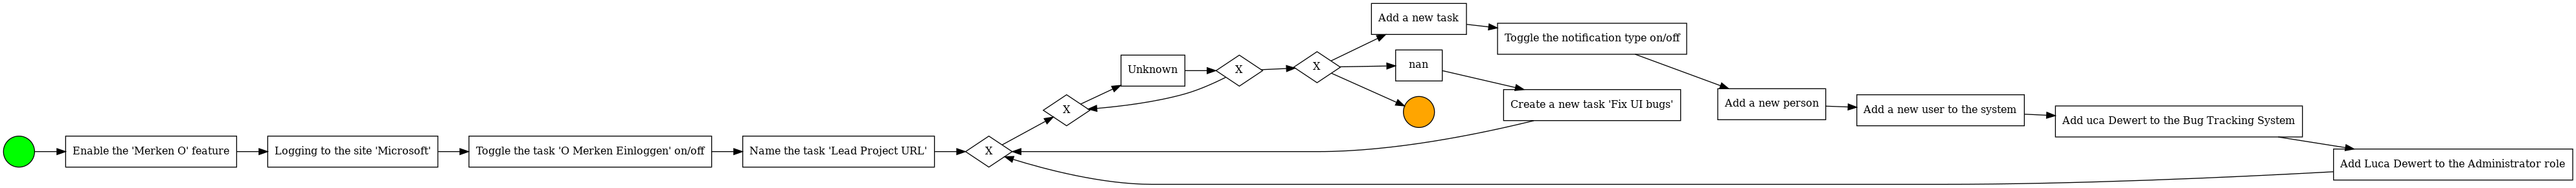

In [12]:
import pm4py

# log = pm4py.read_('<path-to-xes-log-file.xes>')
dataframe = pm4py.format_dataframe(new_event_log, case_id='CaseId', activity_key='Activity', timestamp_key='TimestampLocal')
event_log = pm4py.convert_to_event_log(dataframe)
event_log
process_model = pm4py.discover_bpmn_inductive(event_log)
pm4py.view_bpmn(process_model)